# Analýza logického hradla XOR pomocí Perceptronu
Hradlo XOR je definováno následovně:
- 0 XOR 0 = 0
- 0 XOR 1 = 1
- 1 XOR 0 = 1
- 1 XOR 1 = 0


In [29]:
import sys
import pandas as pd
from IPython.display import display, Markdown
import os
import numpy as np
import matplotlib.pyplot as plt


# Přidání cesty k modelu
sys.path.append(os.path.abspath('../src'))
from src.models.perceptron import Perceptron

# Data pro trénování dílčích hradel (XOR tabulka)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y_or = np.array([-1, 1, 1, 1])     # OR: Aspoň jeden vstup je 1
y_nand = np.array([1, 1, 1, -1])  # NAND: Nejsou oba vstupy 1
y_and = np.array([-1, -1, -1, 1])  # AND: Oba vstupy jsou 1

In [30]:
# Inicializace tří perceptronů tvořících síť
neuron_hidden1 = Perceptron(input_size=2, epochs=10000) # Bude trénován jako OR
neuron_hidden2 = Perceptron(input_size=2, epochs=10000) # Bude trénován jako NAND
neuron_output = Perceptron(input_size=2, epochs=10000)  # Bude trénován jako AND

def get_params_table():
    data = [
        ["neuron_hidden1.weights", list(np.round(neuron_hidden1.weights[1:], 6))],
        ["neuron_hidden2.weights", list(np.round(neuron_hidden2.weights[1:], 6))],
        ["neuron_output.weights", list(np.round(neuron_output.weights[1:], 6))],
        ["neuron_hidden1.bias", round(neuron_hidden1.weights[0], 6)],
        ["neuron_hidden2.bias", round(neuron_hidden2.weights[0], 6)],
        ["neuron_output.bias", round(neuron_output.weights[0], 6)]
    ]
    return pd.DataFrame(data, columns=["Vrstva / Neuron", "Váhy / Bias"])

display(Markdown("### 1. Váhy a bias před trénováním"))
display(get_params_table())

### 1. Váhy a bias před trénováním

,Vrstva / Neuron,Váhy / Bias
0,neuron_hidden1.weights,"[0.002097, -0.022316]"
1,neuron_hidden2.weights,"[0.003136, 0.019437]"
2,neuron_output.weights,"[0.002933, -0.001992]"
3,neuron_hidden1.bias,-0.010459
4,neuron_hidden2.bias,-0.00145
5,neuron_output.bias,-0.012065


In [31]:
# Trénování jednotlivých komponent sítě
neuron_hidden1.train(X, y_or)
neuron_hidden2.train(X, y_nand)
neuron_output.train(X, y_and)

display(Markdown("### 2. Váhy a bias po trénování"))
display(get_params_table())

### 2. Váhy a bias po trénování

,Vrstva / Neuron,Váhy / Bias
0,neuron_hidden1.weights,"[0.202097, 0.177684]"
1,neuron_hidden2.weights,"[-0.196864, -0.180563]"
2,neuron_output.weights,"[0.402933, 0.198008]"
3,neuron_hidden1.bias,-0.010459
4,neuron_hidden2.bias,0.19855
5,neuron_output.bias,-0.412065


In [32]:
def xor_predict(inputs):
    # Skrytá vrstva
    h1 = neuron_hidden1.predict(inputs)
    h2 = neuron_hidden2.predict(inputs)
    # Výstupní vrstva
    return neuron_output.predict(np.array([h1, h2]))

test_results = []
expected_xor = [0, 1, 1, 0]

for i, val in enumerate(X):
    res_sign = xor_predict(val)
    # Převod z -1/1 na 0/1 pro tabulku
    guess = 1 if res_sign == 1 else 0
    
    test_results.append({
        "Vstup": list(val),
        "Odhad sítě (Guess)": guess,
        "Očekávaný výstup": expected_xor[i],
        "Shoduje se?": guess == expected_xor[i]
    })

display(Markdown("### 3. Výsledky testování XOR"))
display(pd.DataFrame(test_results))

### 3. Výsledky testování XOR

,Vstup,Odhad sítě (Guess),Očekávaný výstup,Shoduje se?
0,"[0, 0]",0,0,True
1,"[0, 1]",1,1,True
2,"[1, 0]",1,1,True
3,"[1, 1]",0,0,True


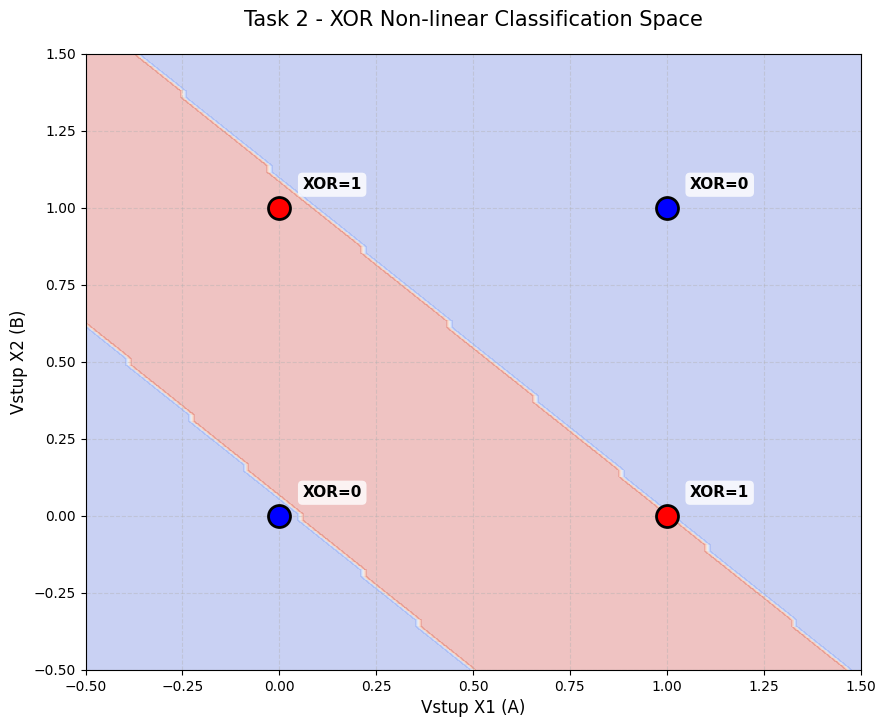

In [34]:
# cestovní adresář 
output_dir_xor = "../results/02_xor_logic"
os.makedirs(output_dir_xor, exist_ok=True)

# 2. vizualizace rozhodovacího prostoru
plt.figure(figsize=(10, 8))

# Definice sítě
x_span = np.linspace(-0.5, 1.5, 100)
y_span = np.linspace(-0.5, 1.5, 100)
xx, yy = np.meshgrid(x_span, y_span)

# Výpočet predikcí naší sítě (OR + NAND -> AND) pro celou plochu
grid = np.c_[xx.ravel(), yy.ravel()]
predictions = np.array([xor_predict(p) for p in grid]).reshape(xx.shape)

# Vykreslení barevných oblastí
plt.contourf(xx, yy, predictions, alpha=0.3, cmap='coolwarm')

# 3. vykreslení datových bodů
for i, val in enumerate(X):
    color = 'red' if expected_xor[i] == 1 else 'blue'
    
    # Vykreslení bodu
    plt.scatter(val[0], val[1], c=color, s=250, edgecolors='black', linewidth=2, zorder=5)
    
    # Textový štítek u bodu
    plt.text(val[0]+0.06, val[1]+0.06, f"XOR={expected_xor[i]}", 
             fontweight='bold', fontsize=11, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3'))

# 4. dekorace grafu
plt.title("Task 2 - XOR Non-linear Classification Space", fontsize=15, pad=20)
plt.xlabel("Vstup X1 (A)", fontsize=12)
plt.ylabel("Vstup X2 (B)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

# 5. uložení výsledného grafu
file_path = os.path.join(output_dir_xor, "xor_decision_result.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

### Zkouška pouze s jedním percetpronem

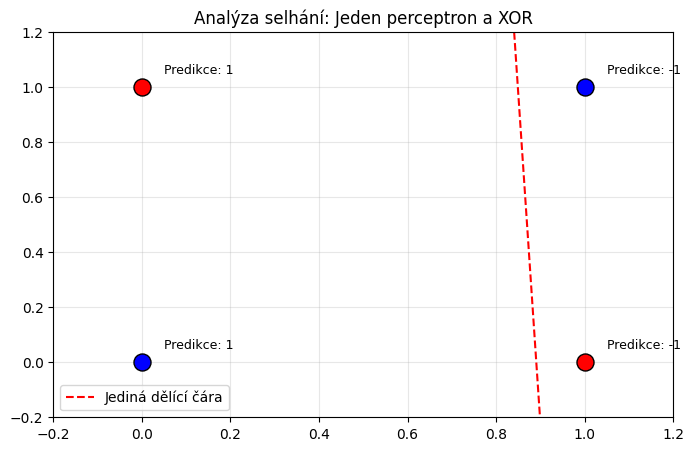

Výsledky jednoho perceptronu:
Vstup [0 0] -> Cíl -1 | Předpověď 1
Vstup [0 1] -> Cíl 1 | Předpověď 1
Vstup [1 0] -> Cíl 1 | Předpověď -1
Vstup [1 1] -> Cíl -1 | Předpověď -1


In [33]:
# 1. Příprava dat pro XOR
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([-1, 1, 1, -1]) 

# 2. Trénink jednoho samostatného perceptronu
single_p = Perceptron(input_size=2, epochs=100)
single_p.train(X_xor, y_xor)

# 3. Vizualizace
plt.figure(figsize=(8, 5))
x_vals = np.linspace(-0.5, 1.5, 100)
w = single_p.weights

# Vykreslení dělící přímky: w1*x + w2*y + w0 = 0 => y = -(w1*x + w0) / w2
plt.plot(x_vals, -(w[1] * x_vals + w[0]) / w[2], 'r--', label="Jediná dělící čára")

# Vykreslení bodů
for i, pt in enumerate(X_xor):
    plt.scatter(pt[0], pt[1], c=('red' if y_xor[i]==1 else 'blue'), s=150, edgecolors='k', zorder=5)
    plt.text(pt[0]+0.05, pt[1]+0.05, f"Predikce: {single_p.predict(pt)}", fontsize=9)

plt.title("Analýza selhání: Jeden perceptron a XOR", fontsize=12)
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Ověření v konzoli
print("Výsledky jednoho perceptronu:")
for pt, target in zip(X_xor, y_xor):
    print(f"Vstup {pt} -> Cíl {target} | Předpověď {single_p.predict(pt)}")